In [1]:
import torch
from torch import nn
import mistral_inf
import transformer_model
import time
import matplotlib.pyplot as plt

import error: No module named 'triton'


In [2]:
mistral_conf = mistral_inf.TransformerArgs(2048, 22, 64, 5632, 32, 4, 1e-5, 32000, 10000, max_batch_size=10)
new_conf = transformer_model.TransformerArgs(precompute_rotary=1024)

In [3]:
model = mistral_inf.Transformer(mistral_conf).to('cuda')
model

Transformer(
  (tok_embeddings): Embedding(32000, 2048)
  (layers): ModuleList(
    (0-21): 22 x TransformerBlock(
      (attention): Attention(
        (wq): Linear(in_features=2048, out_features=2048, bias=False)
        (wk): Linear(in_features=2048, out_features=256, bias=False)
        (wv): Linear(in_features=2048, out_features=256, bias=False)
        (wo): Linear(in_features=2048, out_features=2048, bias=False)
      )
      (feed_forward): FeedForward(
        (w1): Linear(in_features=2048, out_features=5632, bias=False)
        (w2): Linear(in_features=5632, out_features=2048, bias=False)
        (w3): Linear(in_features=2048, out_features=5632, bias=False)
      )
      (attention_norm): RMSNorm()
      (ffn_norm): RMSNorm()
    )
  )
  (norm): RMSNorm()
  (output): Linear(in_features=2048, out_features=32000, bias=False)
)

In [4]:
def convert_block_float16(block):
    attn = block.attention
    attn.wq.weight = nn.Parameter(attn.wq.weight.to(torch.float16))
    attn.wk.weight = nn.Parameter(attn.wk.weight.to(torch.float16))
    attn.wv.weight = nn.Parameter(attn.wv.weight.to(torch.float16))
    attn.wo.weight = nn.Parameter(attn.wo.weight.to(torch.float16))
    feed_forward = block.feed_forward
    feed_forward.w1.weight = nn.Parameter(feed_forward.w1.weight.to(torch.float16))
    feed_forward.w2.weight = nn.Parameter(feed_forward.w2.weight.to(torch.float16))
    feed_forward.w3.weight = nn.Parameter(feed_forward.w3.weight.to(torch.float16))
    attention_norm, ffn_norm = block.attention_norm, block.ffn_norm
    attention_norm.weight = nn.Parameter(attention_norm.weight.to(torch.float16))
    ffn_norm.weight = nn.Parameter(ffn_norm.weight.to(torch.float16))
    return block

In [5]:
for block in model.layers:
    block = convert_block_float16(block)
model.tok_embeddings.weight = nn.Parameter(model.tok_embeddings.weight.to(torch.float16))
model.output.weight = nn.Parameter(model.output.weight.to(torch.float16))
model.norm.weight = nn.Parameter(model.norm.weight.to(torch.float16))

In [6]:
ids = torch.randint(0, 32000-1, (1, 10)).to('cuda', torch.int64)
positions = torch.tensor([i for i in range(10)]).to('cuda', torch.int64)
with torch.no_grad():
    mistral_output = model(ids, positions)

In [7]:
new_model = transformer_model.Transformers(new_conf, model).to('cpu')
new_model

Transformers(
  (positional_encoder): RotaryPositionalEmbeddings()
  (embeddings): Embedding(32000, 2048)
  (layers): ModuleList(
    (0-21): 22 x Block(
      (attention): Attention(
        (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
        (k_proj): Linear(in_features=2048, out_features=256, bias=False)
        (v_proj): Linear(in_features=2048, out_features=256, bias=False)
        (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
      )
      (feed_forward): FeedForward(
        (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
        (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
        (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
        (act_fn): SiLU()
      )
      (attention_norm): RMSNorm()
      (ffn_norm): RMSNorm()
    )
  )
  (norm): RMSNorm()
  (output): Linear(in_features=2048, out_features=32000, bias=False)
)

In [8]:
with torch.no_grad():
    new_output = new_model(ids.to('cpu')).to('cuda')

In [9]:
mistral_probs = torch.nn.functional.softmax(mistral_output, dim=2)
new_probs = torch.nn.functional.softmax(new_output, dim=2)
err_porc = (mistral_probs-new_probs).abs()/torch.min(mistral_probs, new_probs)
print(f"Maximum error: {err_porc.max():.2%}")
print(f"Mean error: {err_porc.mean():.2%}")

Maximum error: 1.33%
Mean error: 0.11%


In [10]:
new_model = transformer_model.Transformers(new_conf)
new_model

Transformers(
  (positional_encoder): RotaryPositionalEmbeddings()
  (embeddings): Embedding(32000, 2048)
  (layers): ModuleList(
    (0-21): 22 x Block(
      (attention): Attention(
        (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
        (k_proj): Linear(in_features=2048, out_features=256, bias=False)
        (v_proj): Linear(in_features=2048, out_features=256, bias=False)
        (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
      )
      (feed_forward): FeedForward(
        (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
        (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
        (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
        (act_fn): SiLU()
      )
      (attention_norm): RMSNorm()
      (ffn_norm): RMSNorm()
    )
  )
  (norm): RMSNorm()
  (output): Linear(in_features=2048, out_features=32000, bias=False)
)

# Test Generate

In [11]:
ids = torch.randint(0, 32000-1, (1, 10)).to('cuda', torch.int64)

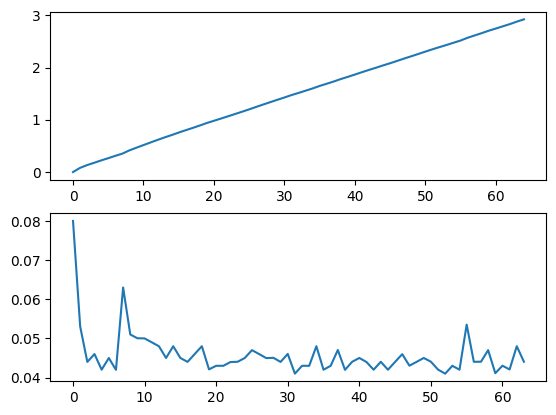

In [12]:
input_ids = ids.to('cuda')
new_model = new_model.to('cuda')
timelist = [time.time()]
with torch.no_grad():
    for i in range(64):
        preds = torch.argmax(new_model(input_ids), dim=2)
        timelist.append(time.time()-timelist[0])
        input_ids = torch.cat((input_ids.squeeze(0), preds[:, -1])).unsqueeze(0)
    timelist[0] = 0
input_ids
plt.subplot(2, 1, 1)
plt.plot(timelist)
plt.subplot(2, 1, 2)
plt.plot([timelist[i]-timelist[i-1] for i in range(1, len(timelist))])

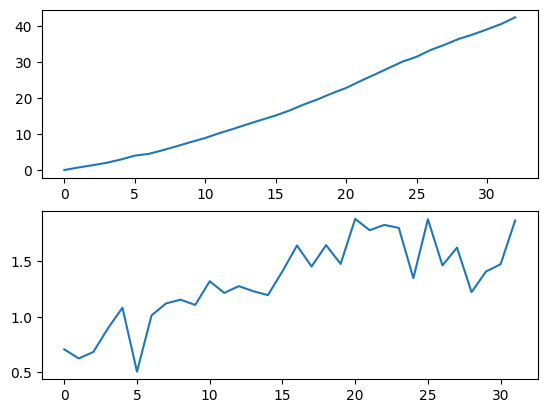

In [14]:
input_ids = ids.to('cpu')
new_model = new_model.to('cpu')
timelist = [time.time()]
with torch.no_grad():
    for i in range(32):
        preds = torch.argmax(new_model(input_ids), dim=2)
        timelist.append(time.time()-timelist[0])
        input_ids = torch.cat((input_ids.squeeze(0), preds[:, -1])).unsqueeze(0)
    timelist[0] = 0
input_ids
plt.subplot(2, 1, 1)
plt.plot(timelist)
plt.subplot(2, 1, 2)
plt.plot([timelist[i]-timelist[i-1] for i in range(1, len(timelist))])